In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bigfile
import os
import tarfile

SIM_PATH = '/home/gayatri/Desktop/codes/galform/tutorial/local/simulations/L100N64_DMO/SNAPS'
plt.style.use('dark_background')

# Load FOF data

In [2]:
halo =  bigfile.File(SIM_PATH+'/PIG_021/FOFGroups')
print(os.listdir(SIM_PATH+'/PIG_021/FOFGroups'))

['GroupID', 'MassCenterPosition', 'Jmom', 'BlackholeMass', 'MinID', 'Imom', 'MassCenterVelocity', 'Mass', 'FirstPos', 'BlackholeAccretionRate', 'MassHeIonized', 'LengthByType', 'MassByType', 'StarFormationRate']


In [3]:
halo_data = bigfile.Dataset(halo, ["GroupID", "MassCenterPosition"])

/home/gayatri/Desktop/codes/.cosmo/lib/python3.12/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


## plot halo centers

In [4]:
x = halo_data["MassCenterPosition"][:][:,0]
y = halo_data["MassCenterPosition"][:][:,1]
z = halo_data["MassCenterPosition"][:][:,2]

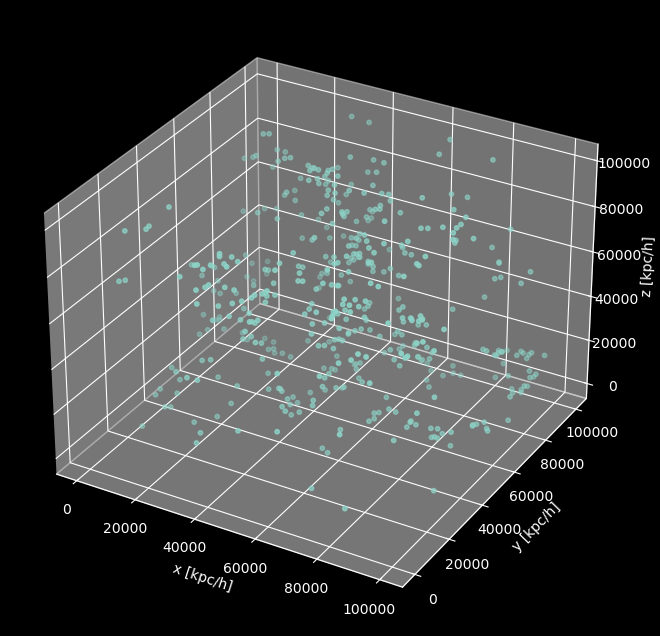

In [5]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')

ax.scatter(x, y, z, s=10)#, c='jet')

ax.set_xlabel("x [kpc/h]")
ax.set_ylabel("y [kpc/h]")
ax.set_zlabel("z [kpc/h]")
plt.show()

# visualize

In [6]:
i = 23
dm =  bigfile.File(SIM_PATH+f'/PART_0{i:02}/1')
# print(os.listdir(SIM_PATH+'/PART_023/1'))
dm_data = bigfile.Dataset(dm, ["ID", "Mass", "Position"])

/home/gayatri/Desktop/codes/.cosmo/lib/python3.12/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)


In [7]:
total_gas_mass = np.sum(dm_data["Mass"][:]*1e10)
total_gas_particles = dm_data["Mass"].size

# print(total_gas_mass)
print("Total gas mass: {:.3e} h-1 Msun".format(total_gas_mass))
print(total_gas_particles)

Total gas mass: 8.751e+16 h-1 Msun
262144


In [8]:
x = dm_data["Position"][:][:,0]
y = dm_data["Position"][:][:,1]
z = dm_data["Position"][:][:,2]

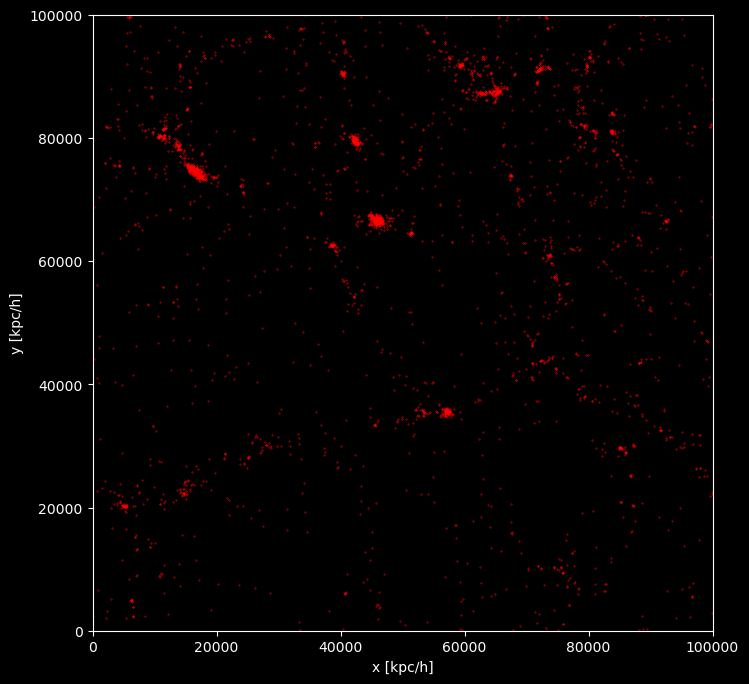

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
# ax = fig.add_subplot(projection='3d')
z_mask = (z > 0.0) & (z < 1000.0)
ax.scatter(x[z_mask], y[z_mask], s=0.1, c='r')

ax.set_xlabel("x [kpc/h]")
ax.set_ylabel("y [kpc/h]")
ax.set_xlim(0,1e5)
ax.set_ylim(0,1e5)
plt.show()

## generate animation

In [ ]:
from IPython.display import HTML
from matplotlib import animation

SNAP_REDSHIFTS = [50,30,20,15,14,13,12,11,10,9,8,7,6,5,4,3,2.5,2.0,1.5,1.0,0.5,0.25,0.1,0]


fig, ax = plt.subplots(figsize=(8,8))
def animate(i):
    ax.clear()
    dm =  bigfile.File(SIM_PATH+f'/PART_0{i:02}/1')
    dm_data = bigfile.Dataset(dm, ["ID", "Mass", "Position"])
    x = dm_data["Position"][:][:,0]
    y = dm_data["Position"][:][:,1]
    z = dm_data["Position"][:][:,2]
    z_mask = (z > 0.0) & (z < 1000.0)
    ax.scatter(x[z_mask], y[z_mask], s=0.1, c='r')
    ax.set_xlabel("x [kpc/h]")
    ax.set_ylabel("y [kpc/h]")
    ax.set_xlim(0,1e5)
    ax.set_ylim(0,1e5)
    ax.set_title(f'z = {SNAP_REDSHIFTS[i]:02}')
    return fig,

# title = '2D Single Species Annihilation\n(w/ Uniform Inital Density)'
# a = ax.imshow(world_evolution[0, 0])
ani = animation.FuncAnimation(fig, animate, frames=24, interval=200, blit=True)
ani.save('outputs/evolve.gif',writer='pillow',fps=20)

In [34]:
HTML(ani.to_html5_video())

/home/gayatri/Desktop/codes/.cosmo/lib/python3.12/site-packages/bigfile/__init__.py:358: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  return pyxbigfile.Dataset.__init__(self, file, dtype=dtype, size=size)
